
# E-Commerce Data Storytelling: Từ tăng trưởng doanh thu đến rủi ro hoàn trả

Notebook này kể lại câu chuyện kinh doanh theo 3 lớp quyết định:

1. **Khách hàng giá trị cao đến từ đâu?**
   Chúng ta cần biết doanh thu đang tập trung vào nhóm khách hàng nào và kênh nào mang về tệp khách hàng chất lượng hơn.
2. **Khuyến mãi có thực sự tạo ra lực kéo?**
   Không chỉ nhìn vào việc có dùng mã giảm giá hay không, mà còn nhìn vào loại khuyến mãi và hiệu suất theo nguồn truy cập.
3. **Rủi ro chất lượng đang nằm ở đâu?**
   Hoàn trả, lý do đổi trả và rating giúp chỉ ra những điểm làm thất thoát biên lợi nhuận.

Mục tiêu là biến dữ liệu rời rạc thành các tín hiệu đủ rõ để ưu tiên hành động.


In [18]:

from pathlib import Path

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings(
    "ignore",
    message="Passing `palette` without assigning `hue` is deprecated",
    category=FutureWarning,
)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

DATA_DIR = Path("../data/raw")

customers = pd.read_csv(DATA_DIR / "customers.csv", parse_dates=["signup_date"])
orders = pd.read_csv(DATA_DIR / "orders.csv", parse_dates=["order_date"])
order_items = pd.read_csv(DATA_DIR / "order_items.csv", low_memory=False)
promotions = pd.read_csv(DATA_DIR / "promotions.csv", parse_dates=["start_date", "end_date"])
returns = pd.read_csv(DATA_DIR / "returns.csv", parse_dates=["return_date"])
products = pd.read_csv(DATA_DIR / "products.csv")
reviews = pd.read_csv(DATA_DIR / "reviews.csv", parse_dates=["review_date"])
web_traffic = pd.read_csv(DATA_DIR / "web_traffic.csv", parse_dates=["date"])

order_items["gross_revenue"] = order_items["quantity"] * order_items["unit_price"]
order_items["net_revenue"] = order_items["gross_revenue"] - order_items["discount_amount"].fillna(0.0)
order_items["promo_used_line"] = order_items[["promo_id", "promo_id_2"]].notna().any(axis=1)

order_value = (
    order_items.groupby("order_id", as_index=False)
    .agg(
        gross_revenue=("gross_revenue", "sum"),
        net_revenue=("net_revenue", "sum"),
        discount_amount=("discount_amount", "sum"),
        promo_used=("promo_used_line", "max"),
    )
)

orders_enriched = (
    orders.merge(order_value, on="order_id", how="left")
    .merge(
        customers[["customer_id", "acquisition_channel", "age_group", "city"]],
        on="customer_id",
        how="left",
    )
)



## 1. Khách hàng cốt lõi của chúng ta là ai?

Nếu doanh thu tập trung quá mạnh vào một nhóm nhỏ khách hàng, chiến lược tăng trưởng nên ưu tiên giữ chân và mở rộng giá trị của nhóm này.
Ngược lại, nếu giá trị trải rộng hơn, ta có thể đầu tư nhiều hơn vào mở rộng acquisition.


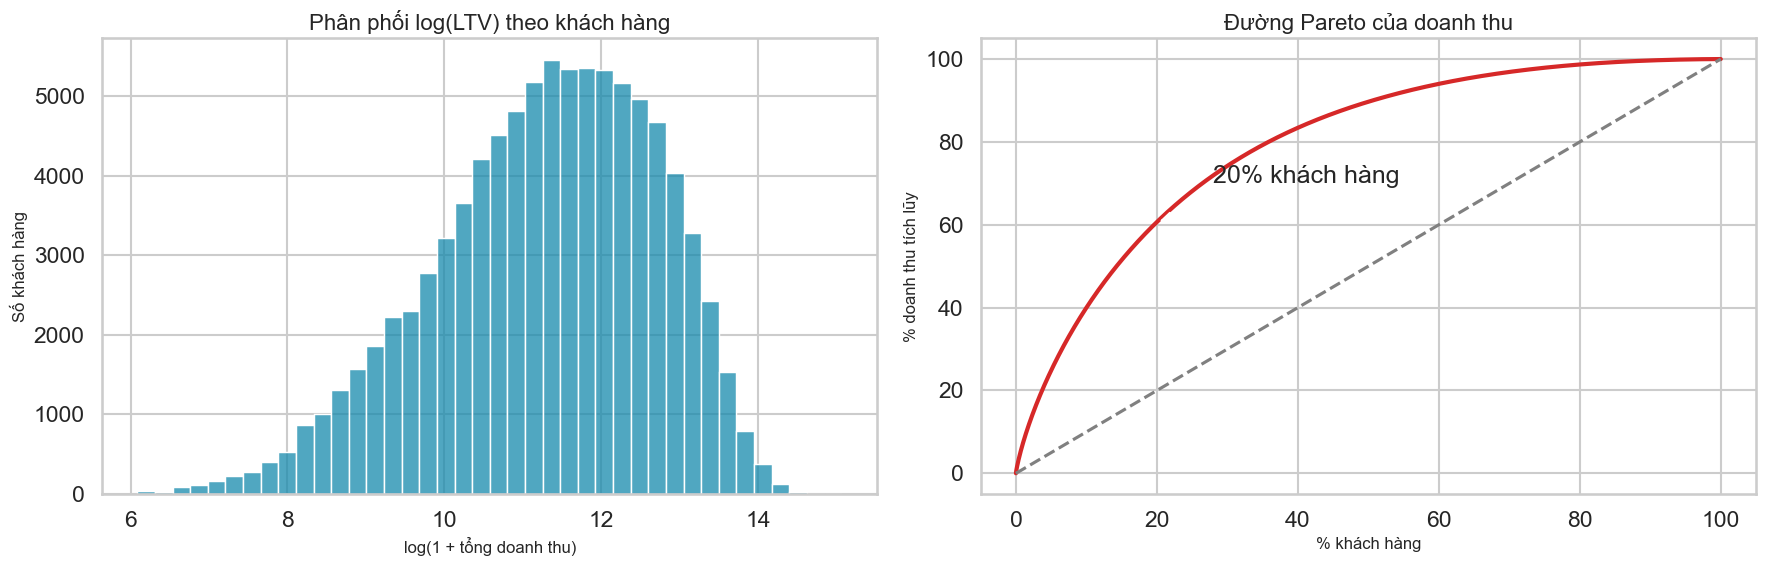

Top 10% khách hàng tạo ra 40.0% doanh thu.
Top 20% khách hàng tạo ra 60.7% doanh thu.
Kênh acquisition có LTV trung bình cao nhất: social_media (175,458).


In [19]:
customer_value = (
    orders_enriched.groupby(["customer_id", "acquisition_channel", "age_group"], as_index=False)
    .agg(
        total_revenue=("net_revenue", "sum"),
        total_orders=("order_id", "nunique"),
        avg_order_value=("net_revenue", "mean"),
    )
    .sort_values("total_revenue", ascending=False)
)

pareto = customer_value[["customer_id", "total_revenue"]].copy().reset_index(drop=True)
pareto["customer_share"] = (pareto.index + 1) / len(pareto)
pareto["revenue_share"] = pareto["total_revenue"].cumsum() / pareto["total_revenue"].sum()

heatmap_data = customer_value.pivot_table(
    index="age_group",
    columns="acquisition_channel",
    values="total_revenue",
    aggfunc="mean",
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(np.log1p(customer_value["total_revenue"]), bins=40, color="#168aad", ax=axes[0])
axes[0].set_title("Phân phối log(LTV) theo khách hàng")
axes[0].set_xlabel("log(1 + tổng doanh thu)")
axes[0].set_ylabel("Số khách hàng")

axes[1].plot(pareto["customer_share"] * 100, pareto["revenue_share"] * 100, color="#d62828", linewidth=3)
axes[1].plot([0, 100], [0, 100], linestyle="--", color="gray")
axes[1].set_title("Đường Pareto của doanh thu")
axes[1].set_xlabel("% khách hàng")
axes[1].set_ylabel("% doanh thu tích lũy")
axes[1].annotate(
    "20% khách hàng",
    xy=(20, pareto.loc[(pareto["customer_share"] <= 0.20), "revenue_share"].max() * 100),
    xytext=(28, 70),
    arrowprops={"arrowstyle": "->"},
)

plt.tight_layout()
plt.show()

top_10_share = pareto.loc[pareto["customer_share"] <= 0.10, "total_revenue"].sum() / pareto["total_revenue"].sum()
top_20_share = pareto.loc[pareto["customer_share"] <= 0.20, "total_revenue"].sum() / pareto["total_revenue"].sum()
best_channel = (
    customer_value.groupby("acquisition_channel", as_index=False)["total_revenue"]
    .mean()
    .sort_values("total_revenue", ascending=False)
    .iloc[0]
)

print(f"Top 10% khách hàng tạo ra {top_10_share:.1%} doanh thu.")
print(f"Top 20% khách hàng tạo ra {top_20_share:.1%} doanh thu.")
print(f"Kênh acquisition có LTV trung bình cao nhất: {best_channel['acquisition_channel']} ({best_channel['total_revenue']:,.0f}).")


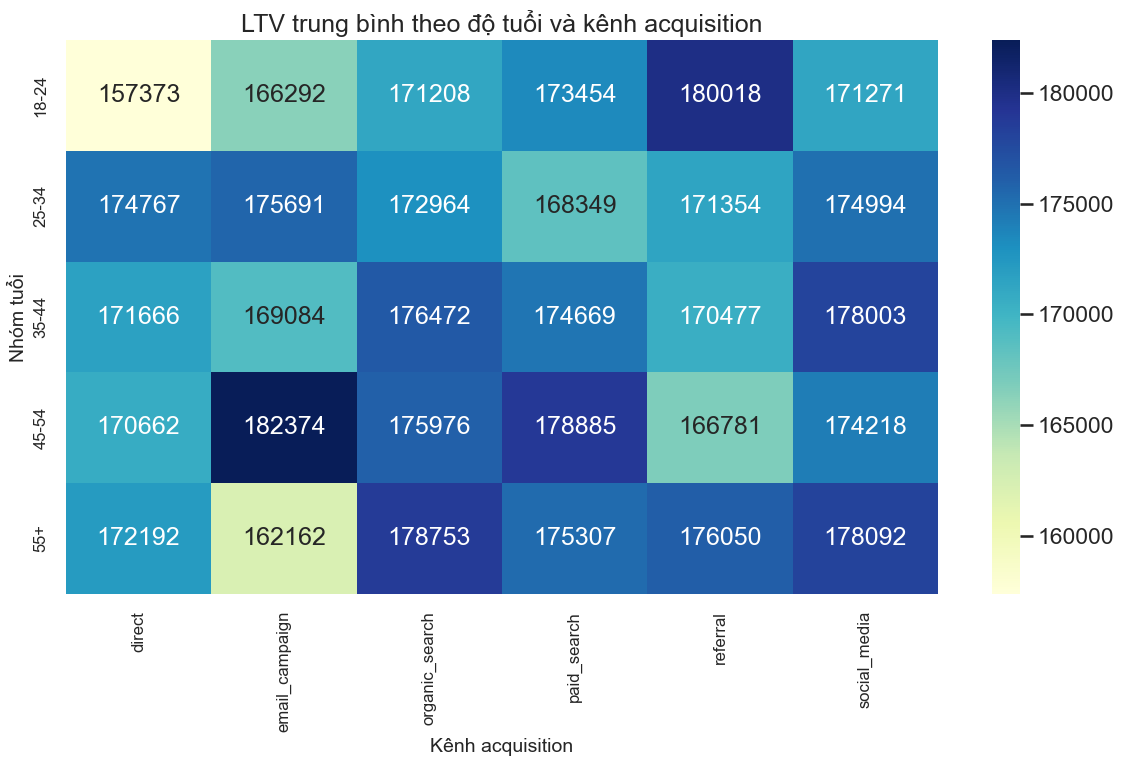

In [20]:
fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu", ax=ax)
ax.set_title("LTV trung bình theo độ tuổi và kênh acquisition", fontsize=18)
ax.set_xlabel("Kênh acquisition", fontsize=14)
ax.set_ylabel("Nhóm tuổi", fontsize=14)
ax.tick_params(axis="both", labelsize=12)

plt.tight_layout()
plt.show()



**Cách đọc phần này:**

- Phân phối LTV lệch phải cho thấy một nhóm khách hàng nhỏ đang kéo phần lớn doanh thu.
- Đường Pareto giúp trả lời nhanh câu hỏi “nếu chỉ giữ chân một nhóm nhỏ nhất, ta nên giữ ai?”.
- Heatmap giúp đội growth nhìn ra tổ hợp `độ tuổi x acquisition channel` nào đáng được nuôi dưỡng thêm thay vì dàn trải ngân sách.



## 2. Khuyến mãi đang hỗ trợ tăng trưởng hay chỉ làm mỏng biên lợi nhuận?

Khuyến mãi không xấu, nhưng cần phân biệt giữa **khuyến mãi tạo thêm đơn hàng chất lượng** và **khuyến mãi chỉ kéo doanh thu ngắn hạn với giá trị đơn thấp**.
Đồng thời, nên xem từng nguồn traffic có đang chuyển đổi tốt hay không.


C:\Users\User\AppData\Local\Temp\ipykernel_9120\2897996060.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=promo_type_usage, x="promo_type", y="order_lines", palette="flare", ax=axes[1])


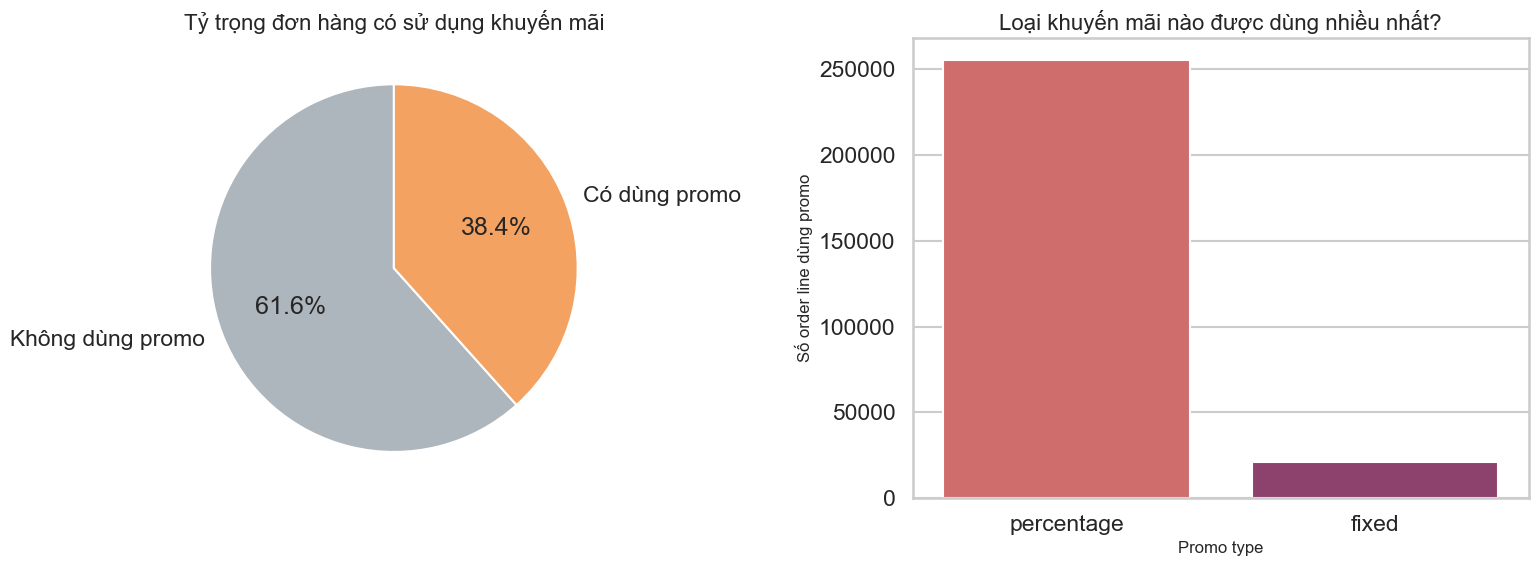

C:\Users\User\AppData\Local\Temp\ipykernel_9120\2897996060.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=promo_order_summary, x="promo_used", y="avg_order_value", palette=["#6c757d", "#e76f51"], ax=ax)
C:\Users\User\AppData\Local\Temp\ipykernel_9120\2897996060.py:82: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Không", "Có"])


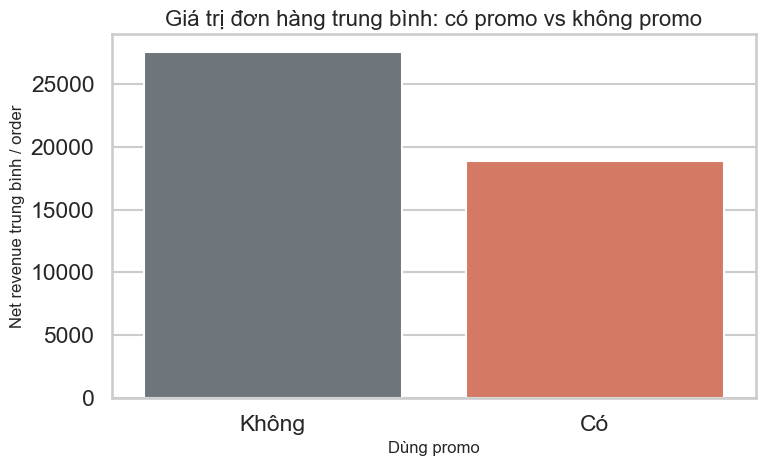

Tỷ lệ đơn hàng có sử dụng promo: 38.4%.
AOV đơn có promo: 18,895; AOV đơn không promo: 27,565.
Nguồn traffic hiệu quả nhất theo chỉ số đơn/1,000 sessions: social_media (10.40).


In [21]:
promo_lines = order_items.melt(
    id_vars=["order_id", "discount_amount"],
    value_vars=["promo_id", "promo_id_2"],
    value_name="promo_code",
).dropna(subset=["promo_code"])

promo_lines = promo_lines.merge(
    promotions[["promo_id", "promo_type", "promo_channel"]],
    left_on="promo_code",
    right_on="promo_id",
    how="left",
)

promo_type_usage = (
    promo_lines.groupby("promo_type", as_index=False)
    .agg(order_lines=("order_id", "count"), total_discount=("discount_amount", "sum"))
    .sort_values("order_lines", ascending=False)
)

promo_order_summary = (
    orders_enriched.groupby("promo_used", as_index=False)
    .agg(
        avg_order_value=("net_revenue", "mean"),
        median_order_value=("net_revenue", "median"),
        avg_discount=("discount_amount", "mean"),
        orders=("order_id", "count"),
    )
)

orders_monthly = (
    orders.assign(month=orders["order_date"].dt.to_period("M").dt.to_timestamp())
    .groupby(["month", "order_source"], as_index=False)
    .size()
    .rename(columns={"size": "orders"})
)
web_monthly = (
    web_traffic.assign(month=web_traffic["date"].dt.to_period("M").dt.to_timestamp())
    .groupby(["month", "traffic_source"], as_index=False)["sessions"]
    .sum()
)
source_efficiency = orders_monthly.merge(
    web_monthly,
    left_on=["month", "order_source"],
    right_on=["month", "traffic_source"],
    how="inner",
)
source_efficiency["orders_per_1000_sessions"] = source_efficiency["orders"] / source_efficiency["sessions"] * 1000

top_sources = (
    source_efficiency.groupby("order_source")["orders_per_1000_sessions"]
    .mean()
    .sort_values(ascending=False)
    .head(4)
    .index
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

promo_share = promo_order_summary.set_index("promo_used")["orders"]
axes[0].pie(
    promo_share.values,
    labels=["Không dùng promo", "Có dùng promo"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#adb5bd", "#f4a261"],
)
axes[0].set_title("Tỷ trọng đơn hàng có sử dụng khuyến mãi")

sns.barplot(data=promo_type_usage, x="promo_type", y="order_lines", palette="flare", ax=axes[1])
axes[1].set_title("Loại khuyến mãi nào được dùng nhiều nhất?")
axes[1].set_xlabel("Promo type")
axes[1].set_ylabel("Số order line dùng promo")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=promo_order_summary, x="promo_used", y="avg_order_value", palette=["#6c757d", "#e76f51"], ax=ax)
ax.set_title("Giá trị đơn hàng trung bình: có promo vs không promo")
ax.set_xlabel("Dùng promo")
ax.set_ylabel("Net revenue trung bình / order")
ax.set_xticklabels(["Không", "Có"])
plt.tight_layout()
plt.show()

best_source = (
    source_efficiency.groupby("order_source", as_index=False)["orders_per_1000_sessions"]
    .mean()
    .sort_values("orders_per_1000_sessions", ascending=False)
    .iloc[0]
)
promo_rate = orders_enriched["promo_used"].mean()
value_lift = promo_order_summary.set_index("promo_used")["avg_order_value"]

print(f"Tỷ lệ đơn hàng có sử dụng promo: {promo_rate:.1%}.")
print(f"AOV đơn có promo: {value_lift.loc[True]:,.0f}; AOV đơn không promo: {value_lift.loc[False]:,.0f}.")
print(f"Nguồn traffic hiệu quả nhất theo chỉ số đơn/1,000 sessions: {best_source['order_source']} ({best_source['orders_per_1000_sessions']:.2f}).")


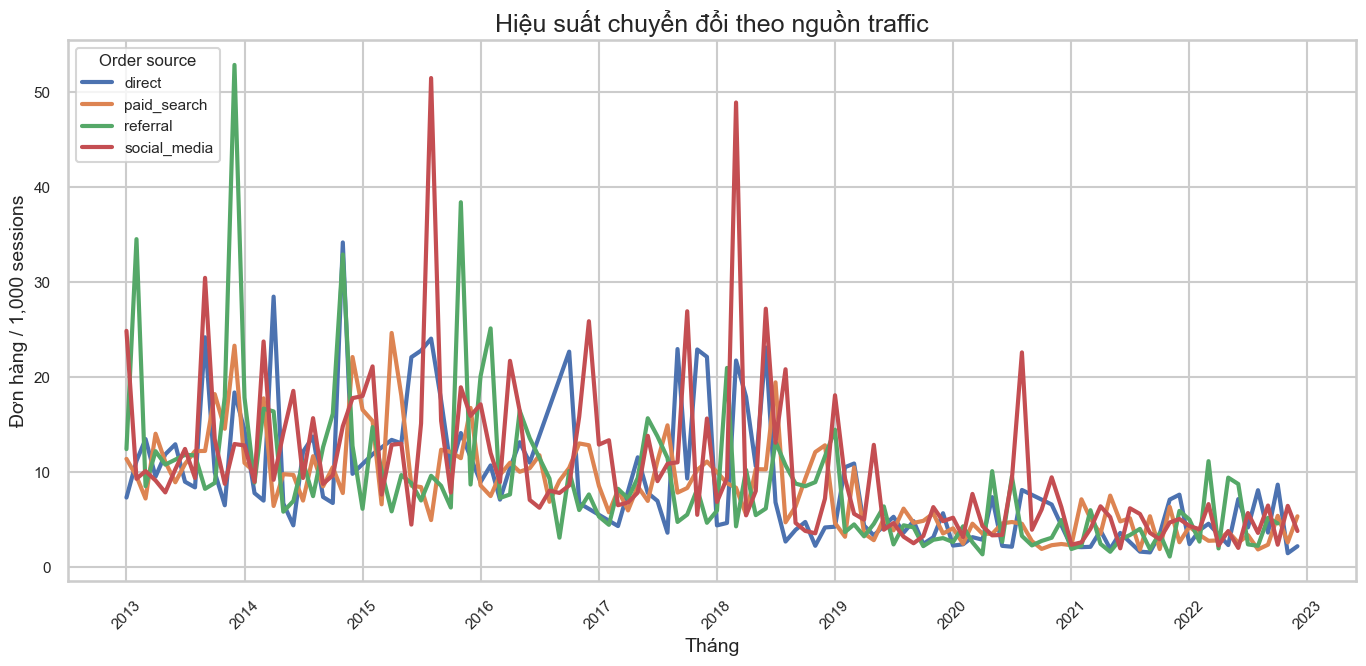

In [22]:
plot_df = source_efficiency[source_efficiency["order_source"].isin(top_sources)]

fig, ax = plt.subplots(figsize=(14, 7))
sns.lineplot(
    data=plot_df,
    x="month",
    y="orders_per_1000_sessions",
    hue="order_source",
    linewidth=3,
    ax=ax,
)
ax.set_title("Hiệu suất chuyển đổi theo nguồn traffic", fontsize=18)
ax.set_xlabel("Tháng", fontsize=14)
ax.set_ylabel("Đơn hàng / 1,000 sessions", fontsize=14)
ax.tick_params(axis="x", rotation=45, labelsize=11)
ax.tick_params(axis="y", labelsize=11)
ax.legend(title="Order source", fontsize=11, title_fontsize=12, loc="upper left")

plt.tight_layout()
plt.show()



**Cách đọc phần này:**

- Nếu tỷ lệ dùng promo cao nhưng AOV thấp hơn đáng kể, promo có thể đang hoạt động như công cụ kích cầu ngắn hạn hơn là công cụ nâng chất lượng doanh thu.
- Phân bố theo `promo_type` giúp đội marketing nhìn ra cơ chế giảm giá nào được thị trường hấp thụ nhiều nhất.
- Đồ thị `orders / 1,000 sessions` cho thấy nguồn nào chuyển đổi tốt thật sự, tránh chỉ nhìn vào traffic volume.



## 3. Hoàn trả đang làm rò rỉ doanh thu ở đâu?

Không phải mọi hoàn trả đều giống nhau. Có nơi vấn đề nằm ở chất lượng sản phẩm, có nơi nằm ở mô tả sản phẩm hoặc kỳ vọng giao hàng.
Kết hợp `return rate`, `refund amount` và `rating` giúp tách đúng nguyên nhân để hành động.


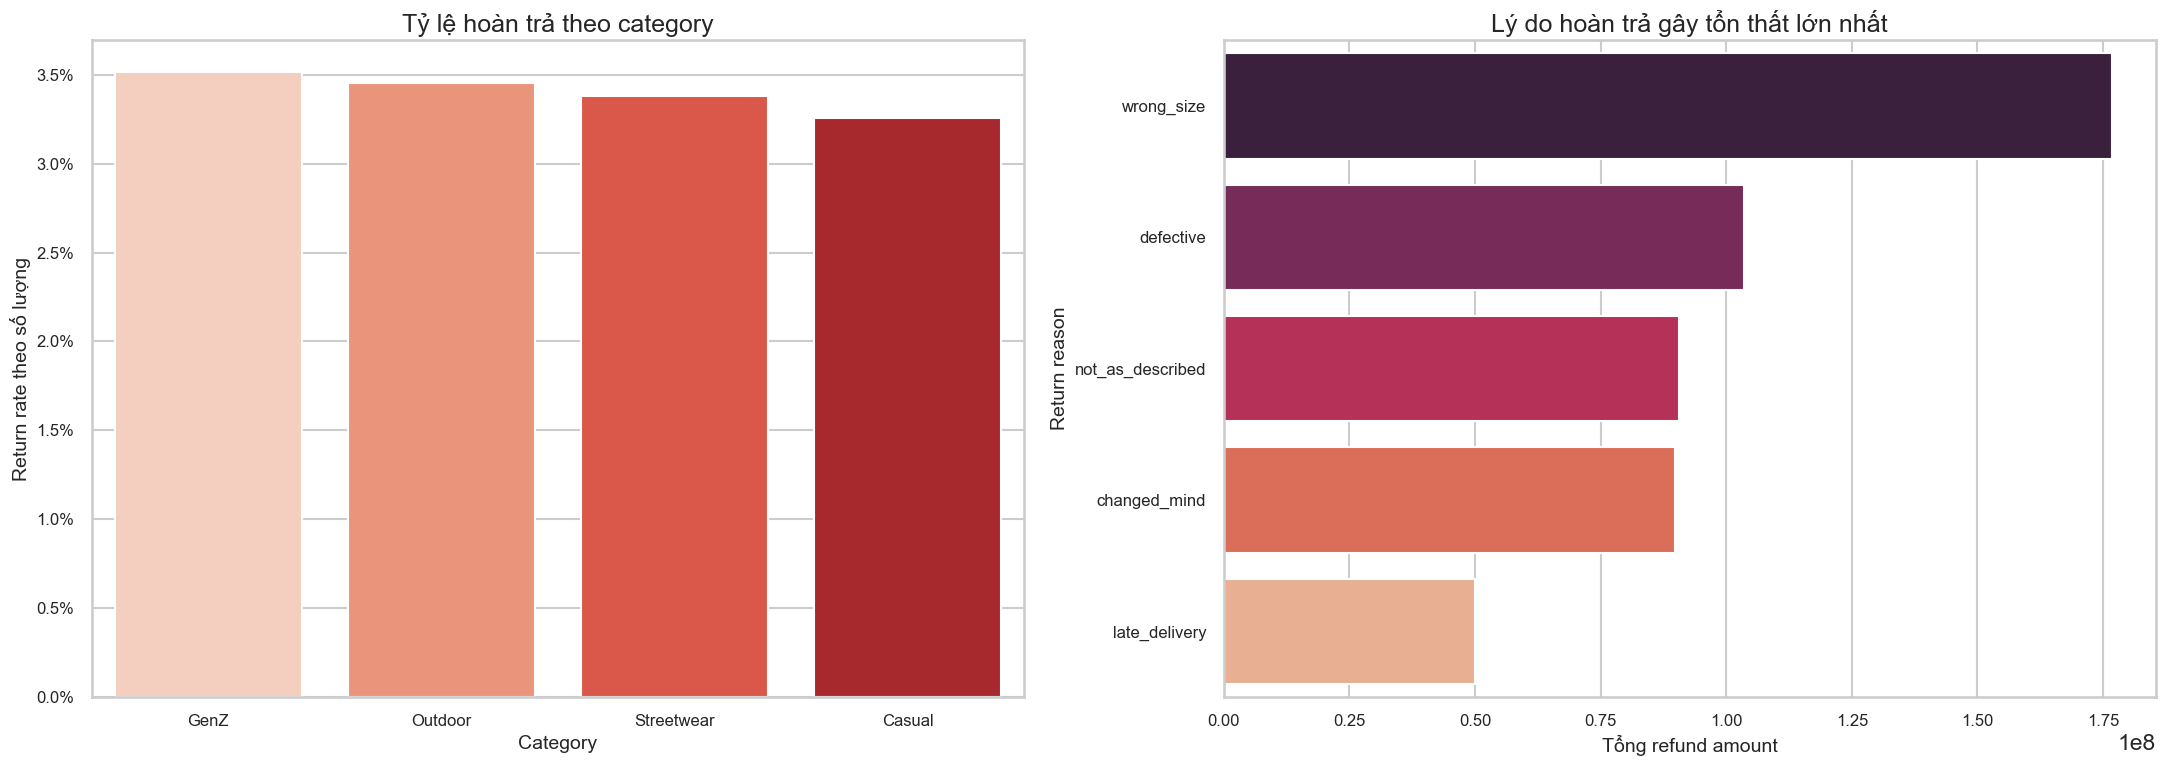

In [23]:

category_sales = (
    order_items.merge(products[["product_id", "category"]], on="product_id", how="left")
    .groupby("category", as_index=False)
    .agg(sold_qty=("quantity", "sum"), net_revenue=("net_revenue", "sum"))
)

category_returns = (
    returns.merge(products[["product_id", "category"]], on="product_id", how="left")
    .groupby("category", as_index=False)
    .agg(
        return_qty=("return_quantity", "sum"),
        refund_amount=("refund_amount", "sum"),
        return_cases=("return_id", "count"),
    )
)

category_reviews = (
    reviews.merge(products[["product_id", "category"]], on="product_id", how="left")
    .groupby("category", as_index=False)
    .agg(avg_rating=("rating", "mean"), review_count=("review_id", "count"))
)

quality_view = (
    category_sales.merge(category_returns, on="category", how="left")
    .merge(category_reviews, on="category", how="left")
    .fillna(0)
)
quality_view["return_rate_qty"] = quality_view["return_qty"] / quality_view["sold_qty"]

reason_view = (
    returns.groupby("return_reason", as_index=False)
    .agg(return_cases=("return_id", "count"), refund_amount=("refund_amount", "sum"))
    .sort_values("refund_amount", ascending=False)
)

plot_quality = quality_view.sort_values("return_rate_qty", ascending=False)
worst_category = plot_quality.iloc[0]
worst_reason = reason_view.iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

sns.barplot(data=plot_quality, x="category", y="return_rate_qty", hue="category", palette="Reds", legend=False, ax=axes[0])
axes[0].set_title("Tỷ lệ hoàn trả theo category", fontsize=18)
axes[0].set_xlabel("Category", fontsize=14)
axes[0].set_ylabel("Return rate theo số lượng", fontsize=14)
axes[0].tick_params(axis="x", labelsize=12)
axes[0].tick_params(axis="y", labelsize=12)
axes[0].yaxis.set_major_formatter(lambda x, pos: f"{x:.1%}")

sns.barplot(data=reason_view, x="refund_amount", y="return_reason", hue="return_reason", palette="rocket", legend=False, ax=axes[1])
axes[1].set_title("Lý do hoàn trả gây tổn thất lớn nhất", fontsize=18)
axes[1].set_xlabel("Tổng refund amount", fontsize=14)
axes[1].set_ylabel("Return reason", fontsize=14)
axes[1].tick_params(axis="x", labelsize=12)
axes[1].tick_params(axis="y", labelsize=12)

plt.tight_layout()
plt.show()


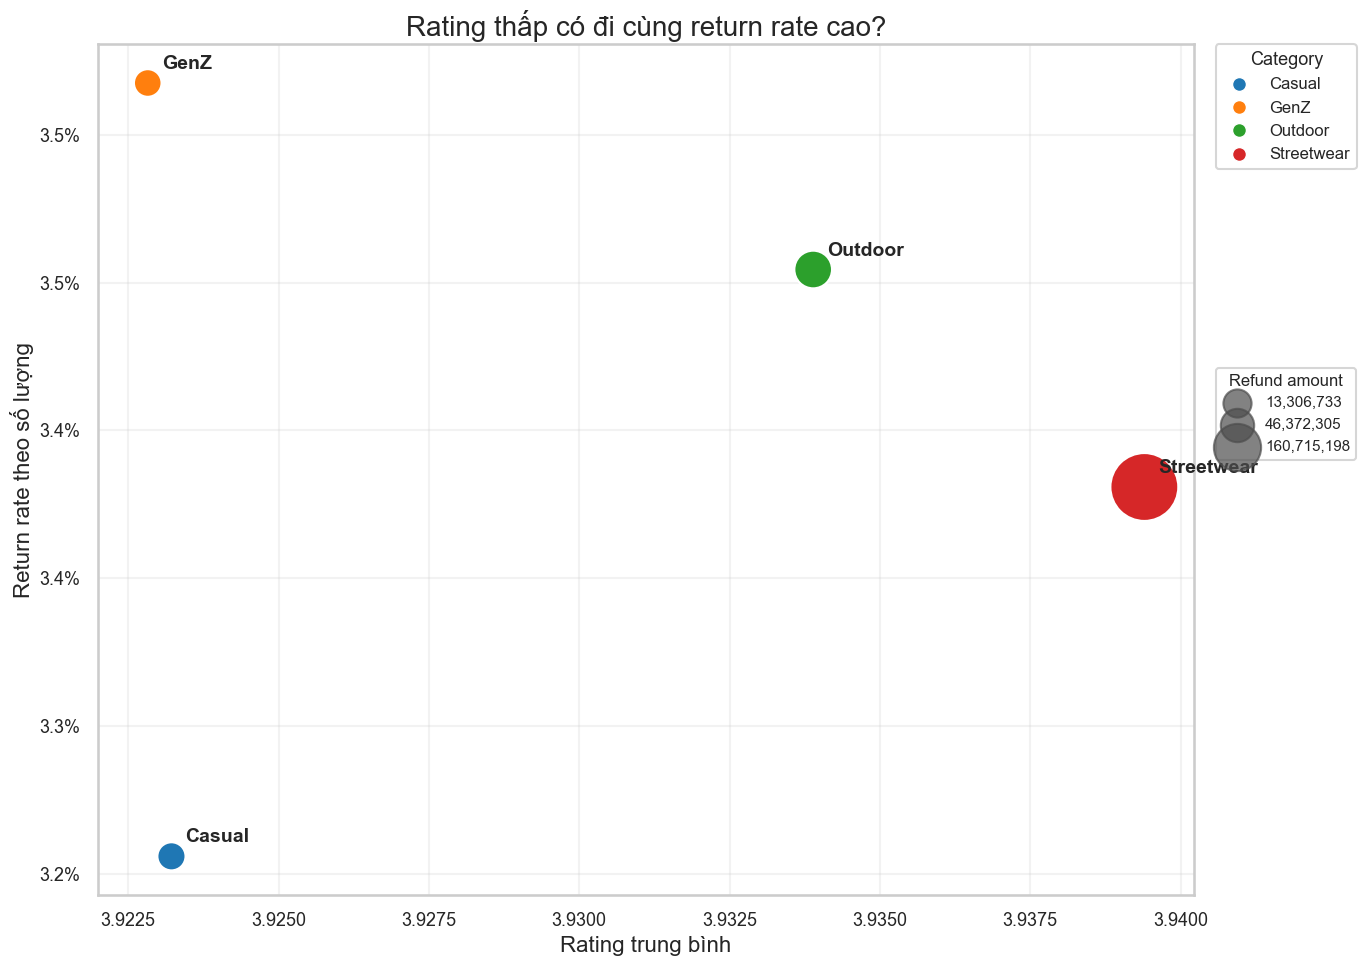

Category có return rate cao nhất: GenZ (3.52%).
Lý do hoàn trả gây refund lớn nhất: wrong_size (176,687,201).
Biểu đồ scatter giúp phân biệt category nào vừa rating thấp vừa tạo áp lực refund lớn để ưu tiên xử lý trước.


In [24]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(14, 10))

sns.scatterplot(
    data=quality_view,
    x="avg_rating",
    y="return_rate_qty",
    size="refund_amount",
    sizes=(400, 2400),
    hue="category",
    palette="tab10",
    legend=False,
    ax=ax,
)
ax.set_title("Rating thấp có đi cùng return rate cao?", fontsize=20)
ax.set_xlabel("Rating trung bình", fontsize=16)
ax.set_ylabel("Return rate theo số lượng", fontsize=16)
ax.tick_params(axis="both", labelsize=13)
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.1%}")
ax.grid(alpha=0.25)

for _, row in quality_view.iterrows():
    ax.annotate(
        row["category"],
        (row["avg_rating"], row["return_rate_qty"]),
        xytext=(10, 10),
        textcoords="offset points",
        fontsize=14,
        fontweight="semibold",
    )

# Build stable custom legends so labels do not overlap or clip.
category_colors = dict(zip(quality_view["category"], sns.color_palette("tab10", n_colors=quality_view["category"].nunique())))
category_handles = [
    Line2D([0], [0], marker="o", color="w", label=cat, markerfacecolor=color, markersize=10)
    for cat, color in category_colors.items()
]
legend1 = ax.legend(
    handles=category_handles,
    title="Category",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    fontsize=12,
    title_fontsize=13,
)
ax.add_artist(legend1)

size_vals = quality_view["refund_amount"].quantile([0.25, 0.5, 0.75]).round(0).astype(int).tolist()
size_min, size_max = quality_view["refund_amount"].min(), quality_view["refund_amount"].max()
scaled_sizes = [400 + (v - size_min) / (size_max - size_min) * (2400 - 400) if size_max > size_min else 900 for v in size_vals]
size_handles = [
    plt.scatter([], [], s=s, color="#4d4d4d", alpha=0.7, label=f"{v:,.0f}")
    for s, v in zip(scaled_sizes, size_vals)
]
ax.legend(
    handles=size_handles,
    title="Refund amount",
    bbox_to_anchor=(1.02, 0.62),
    loc="upper left",
    borderaxespad=0,
    fontsize=11,
    title_fontsize=12,
)

plt.tight_layout()
plt.show()

print(f"Category có return rate cao nhất: {worst_category['category']} ({worst_category['return_rate_qty']:.2%}).")
print(f"Lý do hoàn trả gây refund lớn nhất: {worst_reason['return_reason']} ({worst_reason['refund_amount']:,.0f}).")
print("Biểu đồ scatter giúp phân biệt category nào vừa rating thấp vừa tạo áp lực refund lớn để ưu tiên xử lý trước.")



## Kết luận hành động

1. **Giữ chân nhóm khách hàng tạo doanh thu lõi.** Nếu 20% khách hàng đang tạo ra hơn một nửa doanh thu, CRM và loyalty nên tập trung mạnh vào nhóm này.
2. **Đánh giá lại vai trò của promo trong tăng trưởng.** Nếu đơn có promo cho giá trị thấp hơn, cần đo thêm incremental lift thay vì chỉ nhìn số đơn.
3. **Ưu tiên xử lý các nguyên nhân hoàn trả đắt đỏ nhất.** `wrong_size`, `defective` hay `late_delivery` không chỉ là lỗi vận hành, mà là nguồn rò rỉ lợi nhuận.

Notebook này phù hợp để dùng như một bản kể chuyện dữ liệu ở vòng trình bày: mỗi biểu đồ trả lời một câu hỏi quản trị, không chỉ mô tả số liệu.
